# 02 - Analyse exploratoire et visualisation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/House_Prices.csv")

## Distribution de SalePrice

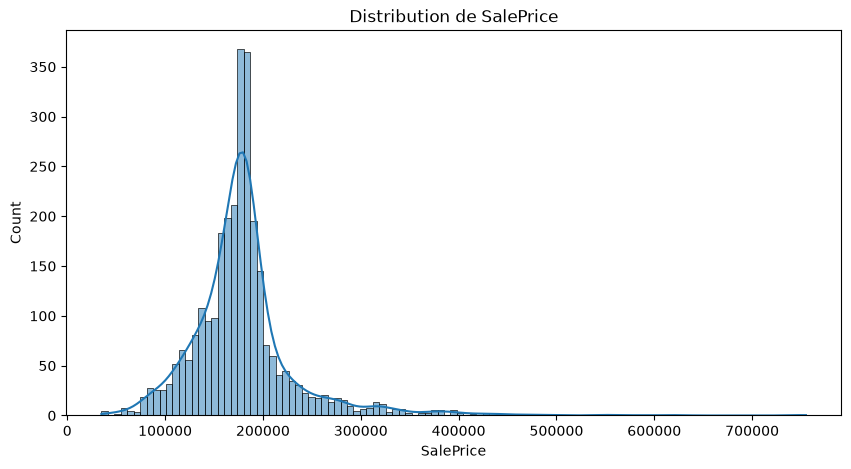

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution de SalePrice")
plt.show()


Interprétation : on observe la forme de la cible et sa dispersion.

## SalePrice après transformation logarithmique

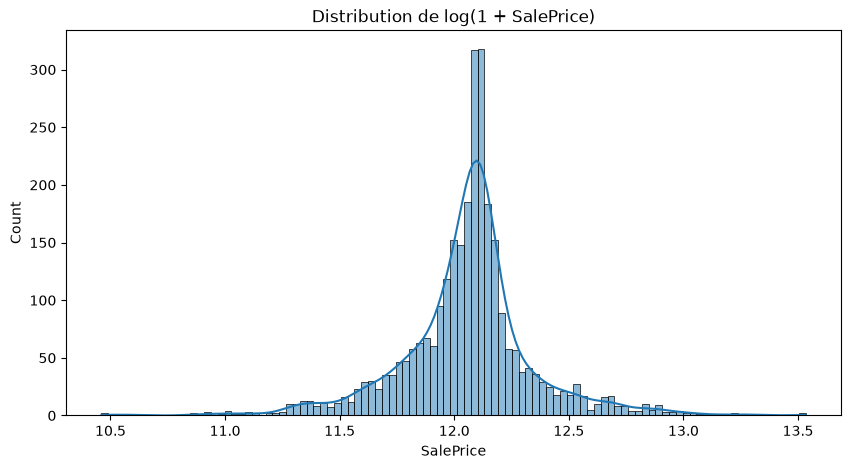

In [4]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df["SalePrice"]), kde=True)
plt.title("Distribution de log(1 + SalePrice)")
plt.show()


## GrLivArea vs SalePrice

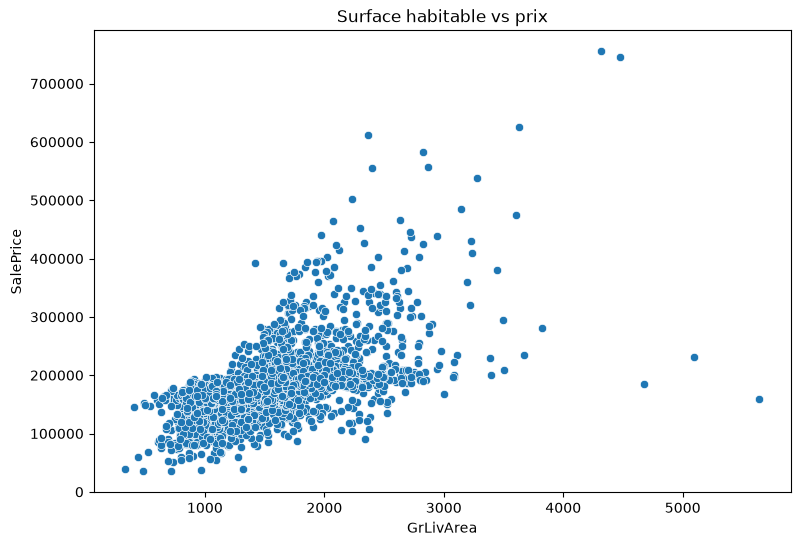

In [10]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")
plt.title("Surface habitable vs prix")
plt.show()


Interprétation : vérifier si la surface habitable est liée au prix.

## OverallQual vs SalePrice

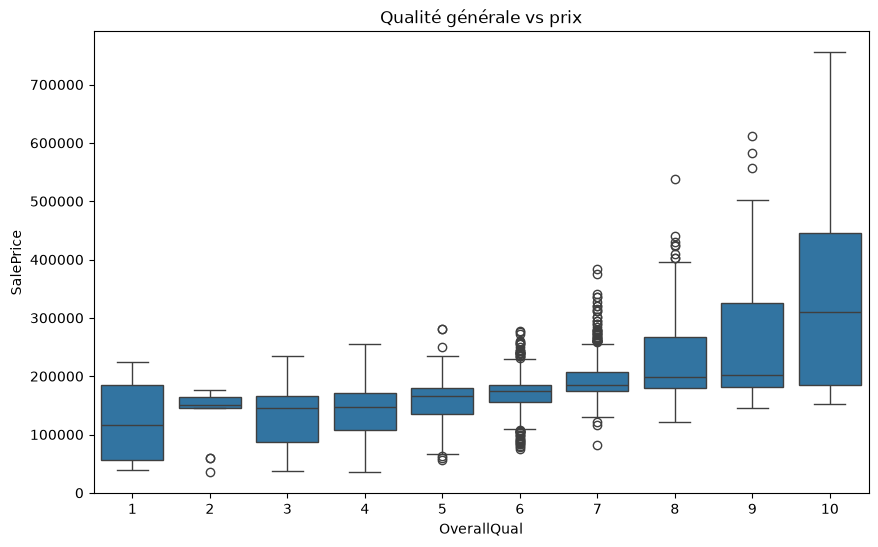

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OverallQual", y="SalePrice")
plt.title("Qualité générale vs prix")
plt.show()


Interprétation : comparer les distributions de prix selon la qualité générale.

## Neighborhood vs SalePrice

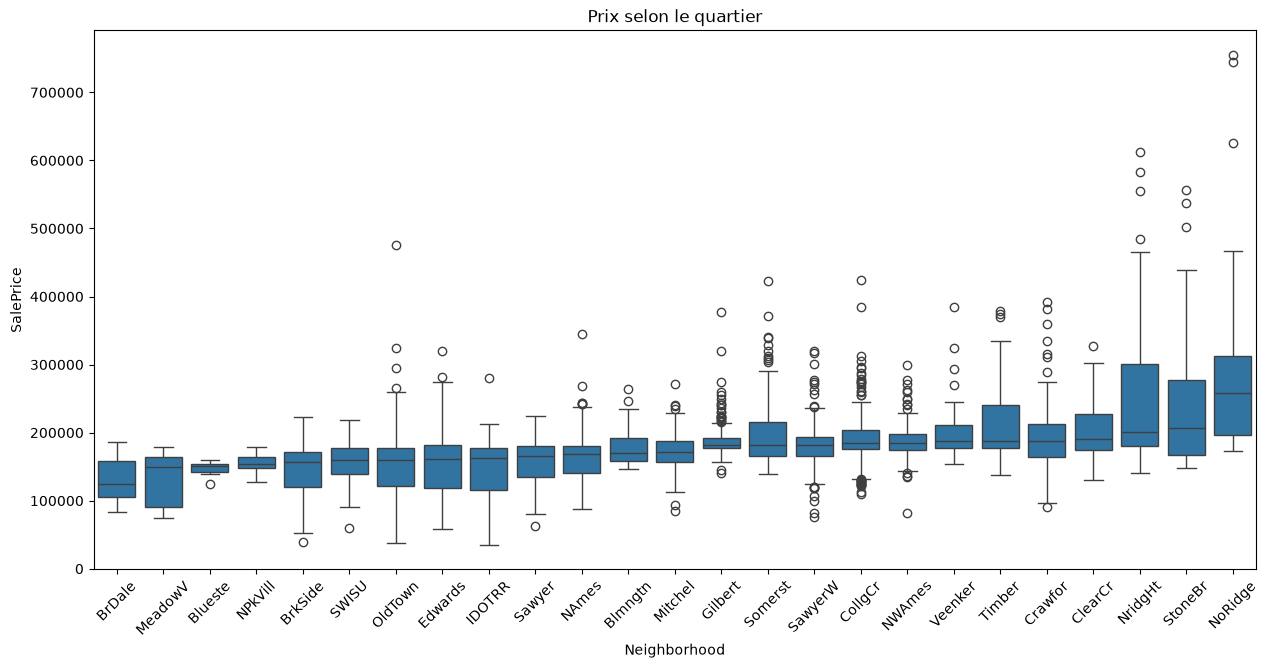

In [18]:
order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index

plt.figure(figsize=(15,7))
sns.boxplot(data=df, x="Neighborhood", y="SalePrice", order=order)
plt.xticks(rotation=45)
plt.title("Prix selon le quartier")
plt.show()


Interprétation : la localisation peut expliquer une partie importante de la variation des prix.

## YearBuilt vs SalePrice

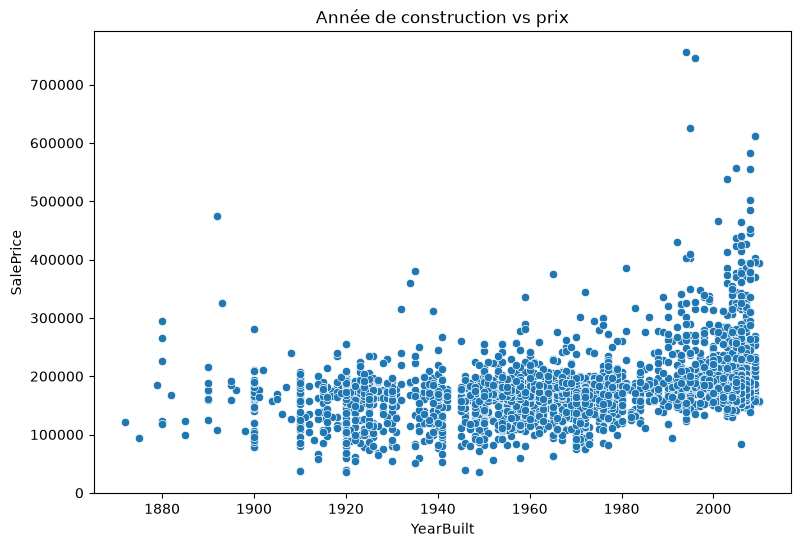

In [20]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="YearBuilt", y="SalePrice")
plt.title("Année de construction vs prix")
plt.show()


## Matrice de corrélation

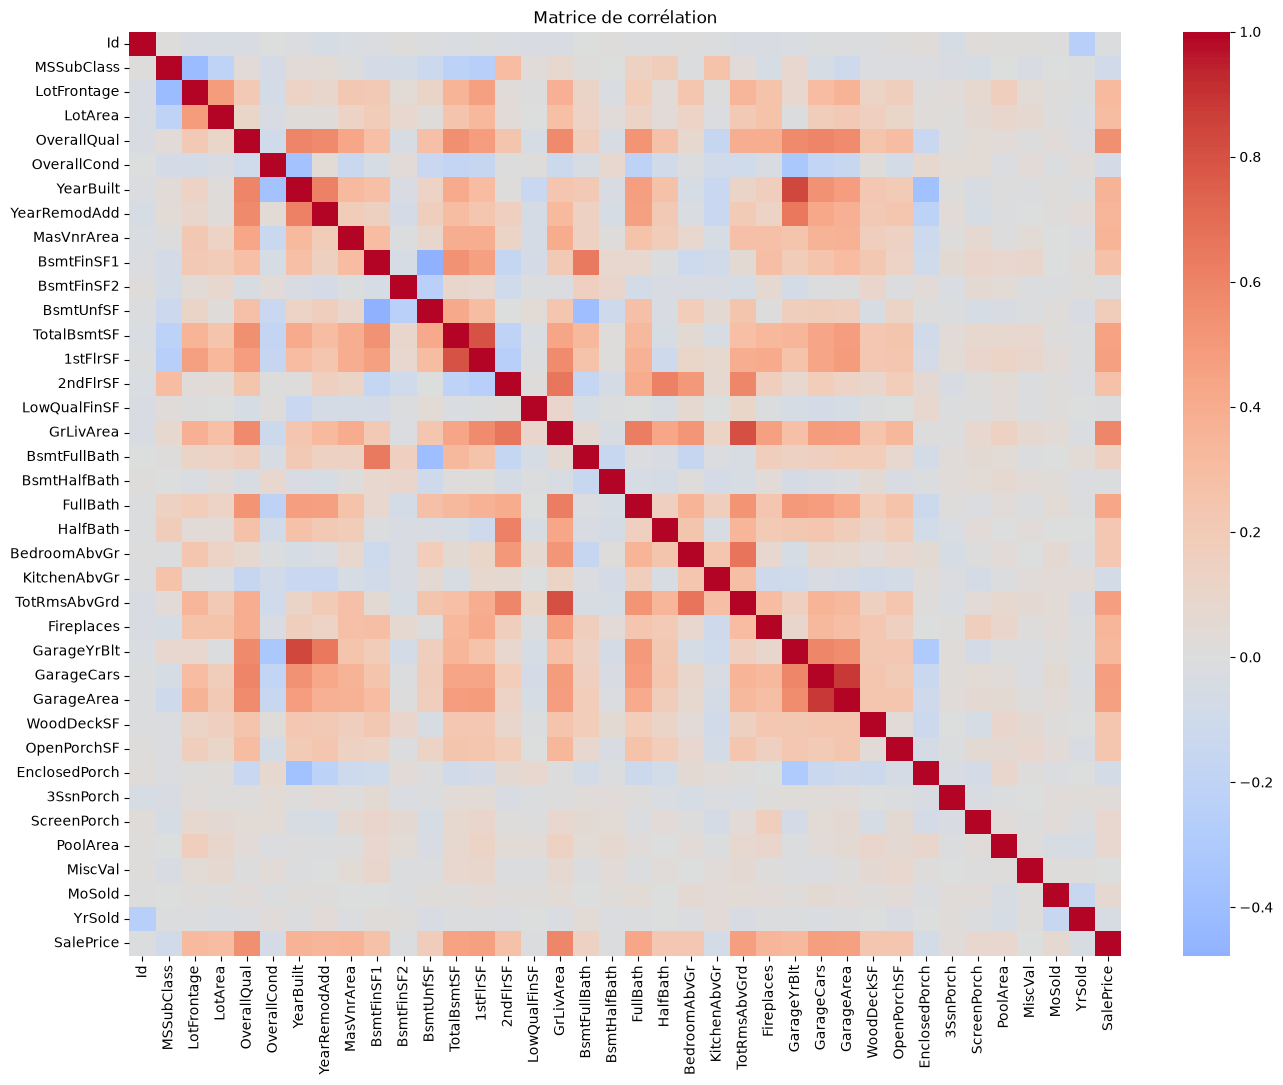

In [27]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(16,12))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()


In [31]:
df.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False).head(10)


SalePrice       1.000000
GrLivArea       0.588010
OverallQual     0.550911
TotRmsAbvGrd    0.469800
GarageCars      0.469249
GarageArea      0.464809
1stFlrSF        0.462865
TotalBsmtSF     0.453224
FullBath        0.433710
YearBuilt       0.362066
Name: SalePrice, dtype: float64

Interprétation : identifier les variables numériques les plus liées à `SalePrice` et les corrélations fortes entre variables.